##### Import the libraries

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import holidays
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import (mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import joblib
import os
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

##### Load the datasets

In [18]:
best_predictions = pd.read_csv(
    r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Models\Best Models\Best Models Predictions\best_models_predictions.csv"
)

best_predictions.head()

,hospital_name,hospital_id,unit,date,actual,predicted,model
0,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-25,21.208333,22.281654,SARIMA
1,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-26,23.375000,21.692058,SARIMA
2,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-27,19.000000,19.730131,SARIMA
3,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-28,18.875000,17.138078,SARIMA
4,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-29,16.916667,16.988289,SARIMA


In [19]:
staffing_df = pd.read_csv(
    r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\Cleaned\staffing_resource_cleaned.csv")

staffing_df["datetime"] = pd.to_datetime(staffing_df["date"])
staffing_df.head()

,date,hospital_id,ward,staff_role,planned_staff,actual_staff,safe_ratio_met,staffing_year,staffing_month,staffing_quarter,staffing_weekday,datetime
0,2024-01-01,HHN-BIR-01,Cardiology Ward,Registered Nurse,10,10,True,2024,January,1,Monday,2024-01-01
1,2024-01-01,HHN-BIR-01,Cardiology Ward,Healthcare Assistant,5,5,True,2024,January,1,Monday,2024-01-01
2,2024-01-01,HHN-BIR-01,Cardiology Ward,Doctor,4,4,True,2024,January,1,Monday,2024-01-01
3,2024-01-01,HHN-BIR-01,Cardiology Ward,Allied Health Professional,1,1,True,2024,January,1,Monday,2024-01-01
4,2024-01-02,HHN-BIR-01,Cardiology Ward,Registered Nurse,10,8,False,2024,January,1,Tuesday,2024-01-02


##### Create Unit column

In [20]:
staffing_df["unit"] = (staffing_df["hospital_id"] + "_" + staffing_df["ward"])
staffing_df.head()

,date,hospital_id,ward,staff_role,planned_staff,actual_staff,safe_ratio_met,staffing_year,staffing_month,staffing_quarter,staffing_weekday,datetime,unit
0,2024-01-01,HHN-BIR-01,Cardiology Ward,Registered Nurse,10,10,True,2024,January,1,Monday,2024-01-01,HHN-BIR-01_Cardiology Ward
1,2024-01-01,HHN-BIR-01,Cardiology Ward,Healthcare Assistant,5,5,True,2024,January,1,Monday,2024-01-01,HHN-BIR-01_Cardiology Ward
2,2024-01-01,HHN-BIR-01,Cardiology Ward,Doctor,4,4,True,2024,January,1,Monday,2024-01-01,HHN-BIR-01_Cardiology Ward
3,2024-01-01,HHN-BIR-01,Cardiology Ward,Allied Health Professional,1,1,True,2024,January,1,Monday,2024-01-01,HHN-BIR-01_Cardiology Ward
4,2024-01-02,HHN-BIR-01,Cardiology Ward,Registered Nurse,10,8,False,2024,January,1,Tuesday,2024-01-02,HHN-BIR-01_Cardiology Ward


##### Aggregate staffing to ward level

In [21]:
staffing_daily = (
    staffing_df
    .groupby(["date", "hospital_id", "ward", "unit"])
    .agg({
        "planned_staff": "sum",
        "actual_staff": "sum",
        "safe_ratio_met": "all"
    })
    .reset_index()
)

staffing_daily.head()

,date,hospital_id,ward,unit,planned_staff,actual_staff,safe_ratio_met
0,2024-01-01,HHN-BIR-01,Cardiology Ward,HHN-BIR-01_Cardiology Ward,20,20,True
1,2024-01-01,HHN-BIR-01,Day Case Unit,HHN-BIR-01_Day Case Unit,1,1,True
2,2024-01-01,HHN-BIR-01,General Medicine Ward A,HHN-BIR-01_General Medicine Ward A,6,6,True
3,2024-01-01,HHN-BIR-01,General Medicine Ward B,HHN-BIR-01_General Medicine Ward B,6,6,True
4,2024-01-01,HHN-BIR-01,ICU,HHN-BIR-01_ICU,12,10,False


##### Match forecast dates

In [22]:
latest_staffing = (
    staffing_daily
    .sort_values("date")
    .groupby("unit")
    .tail(1)
)

latest_staffing.head()

,date,hospital_id,ward,unit,planned_staff,actual_staff,safe_ratio_met
29227,2025-12-31,HHN-LON-02,General Medicine Ward B,HHN-LON-02_General Medicine Ward B,7,7,True
29226,2025-12-31,HHN-LON-02,General Medicine Ward A,HHN-LON-02_General Medicine Ward A,7,6,False
29225,2025-12-31,HHN-LON-02,Day Case Unit,HHN-LON-02_Day Case Unit,1,1,True
29221,2025-12-31,HHN-LON-01,Oncology Ward,HHN-LON-01_Oncology Ward,19,19,True
29223,2025-12-31,HHN-LON-01,Orthopaedics Ward B,HHN-LON-01_Orthopaedics Ward B,12,10,False


##### Match forcasts with staffing

In [25]:
staffing_alignment = best_predictions.merge(
    latest_staffing[["unit", "planned_staff", "actual_staff", "safe_ratio_met"]],
    on="unit",
    how="left"
)

staffing_alignment.head()

,hospital_name,hospital_id,unit,date,actual,predicted,model,planned_staff,actual_staff,safe_ratio_met
0,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-25,21.208333,22.281654,SARIMA,20,20,True
1,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-26,23.375000,21.692058,SARIMA,20,20,True
2,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-27,19.000000,19.730131,SARIMA,20,20,True
3,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-28,18.875000,17.138078,SARIMA,20,20,True
4,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-29,16.916667,16.988289,SARIMA,20,20,True


##### Calculate workload per staff member

In [27]:
staffing_alignment["beds_per_planned_staff"] = (
    staffing_alignment["predicted"]
    / staffing_alignment["planned_staff"]
)

staffing_alignment["beds_per_actual_staff"] = (
    staffing_alignment["predicted"]
    / staffing_alignment["actual_staff"]
)

staffing_alignment.head()

,hospital_name,hospital_id,unit,date,actual,predicted,model,planned_staff,actual_staff,safe_ratio_met,beds_per_planned_staff,beds_per_actual_staff
0,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-25,21.208333,22.281654,SARIMA,20,20,True,1.114083,1.114083
1,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-26,23.375000,21.692058,SARIMA,20,20,True,1.084603,1.084603
2,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-27,19.000000,19.730131,SARIMA,20,20,True,0.986507,0.986507
3,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-28,18.875000,17.138078,SARIMA,20,20,True,0.856904,0.856904
4,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-29,16.916667,16.988289,SARIMA,20,20,True,0.849414,0.849414


##### Define safe threshold

In [28]:
SAFE_THRESHOLD = 4.0
WARNING_THRESHOLD = 5.0

conditions = [
    staffing_alignment["beds_per_actual_staff"] <= SAFE_THRESHOLD,
    staffing_alignment["beds_per_actual_staff"] <= WARNING_THRESHOLD
]

choices = [
    "Safe",
    "Warning"
]

staffing_alignment["feasibility_flag"] = np.select(
    conditions,
    choices,
    default="Critical Gap"
)

staffing_alignment.head()

,hospital_name,hospital_id,unit,date,actual,predicted,model,planned_staff,actual_staff,safe_ratio_met,beds_per_planned_staff,beds_per_actual_staff,feasibility_flag
0,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-25,21.208333,22.281654,SARIMA,20,20,True,1.114083,1.114083,Safe
1,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-26,23.375000,21.692058,SARIMA,20,20,True,1.084603,1.084603,Safe
2,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-27,19.000000,19.730131,SARIMA,20,20,True,0.986507,0.986507,Safe
3,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-28,18.875000,17.138078,SARIMA,20,20,True,0.856904,0.856904,Safe
4,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-29,16.916667,16.988289,SARIMA,20,20,True,0.849414,0.849414,Safe


##### Incorporate safe-ratio information

In [29]:
staffing_alignment["historical_safe_ratio"] = np.where(
    staffing_alignment["safe_ratio_met"],
    "Historically Safe",
    "Historically Unsafe"
)

##### Overall staffing status

In [30]:
staffing_alignment["overall_status"] = np.where(
    (staffing_alignment["feasibility_flag"] == "Critical Gap") |
    (~staffing_alignment["safe_ratio_met"]),
    "Unsafe",
    "Operationally Feasible"
)

staffing_alignment.head()

,hospital_name,hospital_id,unit,date,actual,predicted,model,planned_staff,actual_staff,safe_ratio_met,beds_per_planned_staff,beds_per_actual_staff,feasibility_flag,historical_safe_ratio,overall_status
0,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-25,21.208333,22.281654,SARIMA,20,20,True,1.114083,1.114083,Safe,Historically Safe,Operationally Feasible
1,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-26,23.375000,21.692058,SARIMA,20,20,True,1.084603,1.084603,Safe,Historically Safe,Operationally Feasible
2,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-27,19.000000,19.730131,SARIMA,20,20,True,0.986507,0.986507,Safe,Historically Safe,Operationally Feasible
3,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-28,18.875000,17.138078,SARIMA,20,20,True,0.856904,0.856904,Safe,Historically Safe,Operationally Feasible
4,Horizon Birmingham,HHN-BIR-01,HHN-BIR-01_Cardiology Ward,2025-12-29,16.916667,16.988289,SARIMA,20,20,True,0.849414,0.849414,Safe,Historically Safe,Operationally Feasible


##### Summary by hospital

In [32]:
staffing_alignment["hospital_id"] = staffing_alignment["unit"].str.extract(r"^(HHN-[A-Z]+-\d+)")

hospital_summary = (
    staffing_alignment
    .groupby(["hospital_id", "overall_status"])
    .size()
    .reset_index(name="days_count")
)

hospital_summary

,hospital_id,overall_status,days_count
0,HHN-BIR-01,Operationally Feasible,118
1,HHN-BIR-01,Unsafe,7
2,HHN-EDI-01,Operationally Feasible,79
3,HHN-LON-01,Operationally Feasible,81
4,HHN-LON-01,Unsafe,67
5,HHN-LON-02,Operationally Feasible,187
6,HHN-LON-02,Unsafe,7
7,HHN-MAN-01,Operationally Feasible,81
8,HHN-MAN-01,Unsafe,21


##### Summary by ward

In [34]:
ward_summary = (
    staffing_alignment
    .groupby(["unit", "overall_status"])
    .size()
    .reset_index(name="days_count")
)

ward_summary.head()

,unit,overall_status,days_count
0,HHN-BIR-01_Cardiology Ward,Operationally Feasible,7
1,HHN-BIR-01_Day Case Unit,Operationally Feasible,30
2,HHN-BIR-01_General Medicine Ward A,Operationally Feasible,7
3,HHN-BIR-01_General Medicine Ward B,Operationally Feasible,30
4,HHN-BIR-01_ICU,Operationally Feasible,7


##### Highest risks wards

In [37]:
highest_risk = (
    staffing_alignment
    .sort_values("beds_per_actual_staff", ascending=False)
    .head(10)
)

highest_risk[[
    "unit",
    "date",
    "predicted",
    "actual_staff",
    "beds_per_actual_staff",
    "overall_status"
]]

,unit,date,predicted,actual_staff,beds_per_actual_staff,overall_status
109,HHN-MAN-01_General Medicine Ward A,2025-12-29,18.689375,6,3.114896,Unsafe
110,HHN-MAN-01_General Medicine Ward A,2025-12-30,18.579860,6,3.096643,Unsafe
108,HHN-MAN-01_General Medicine Ward A,2025-12-28,18.392302,6,3.065384,Unsafe
111,HHN-MAN-01_General Medicine Ward A,2025-12-31,18.145499,6,3.024250,Unsafe
123,HHN-MAN-01_General Medicine Ward B,2025-12-29,21.000000,7,3.000000,Unsafe
124,HHN-MAN-01_General Medicine Ward B,2025-12-30,21.000000,7,3.000000,Unsafe
102,HHN-LON-02_General Medicine Ward A,2025-12-29,17.916667,6,2.986111,Unsafe
104,HHN-LON-02_General Medicine Ward A,2025-12-31,17.916667,6,2.986111,Unsafe
103,HHN-LON-02_General Medicine Ward A,2025-12-30,17.916667,6,2.986111,Unsafe
107,HHN-MAN-01_General Medicine Ward A,2025-12-27,17.905476,6,2.984246,Unsafe


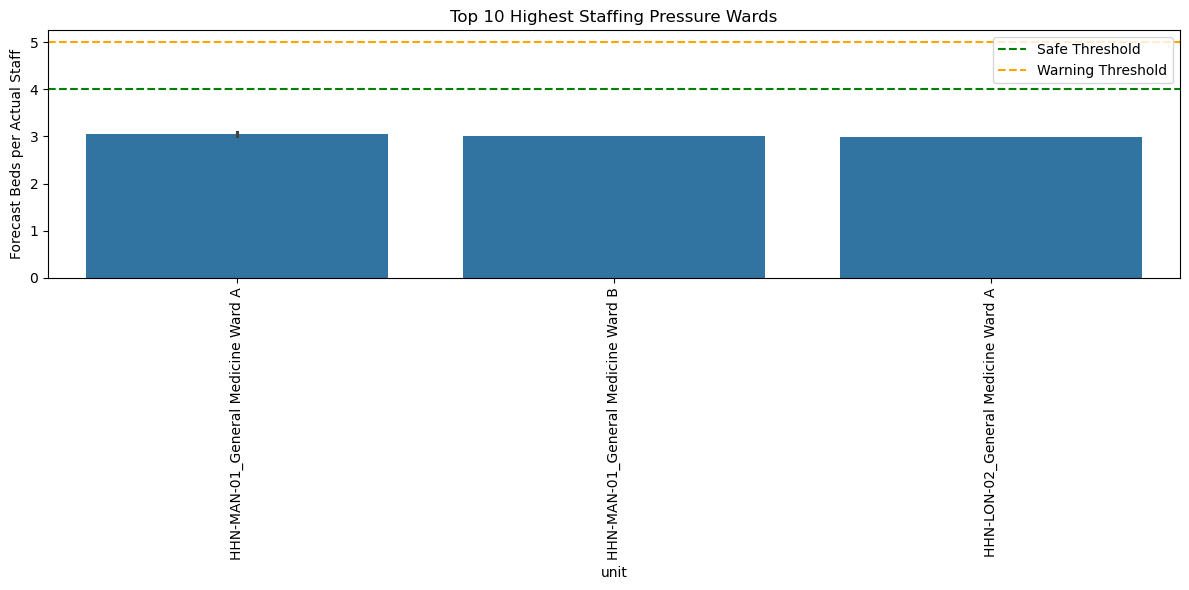

In [39]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=highest_risk,
    x="unit",
    y="beds_per_actual_staff"
)

plt.axhline(SAFE_THRESHOLD, color="green", linestyle="--", label="Safe Threshold")
plt.axhline(WARNING_THRESHOLD, color="orange", linestyle="--", label="Warning Threshold")

plt.xticks(rotation=90)
plt.ylabel("Forecast Beds per Actual Staff")
plt.title("Top 10 Highest Staffing Pressure Wards")
plt.legend()
plt.tight_layout()
plt.show()

##### Daily pressure trend (example ward)

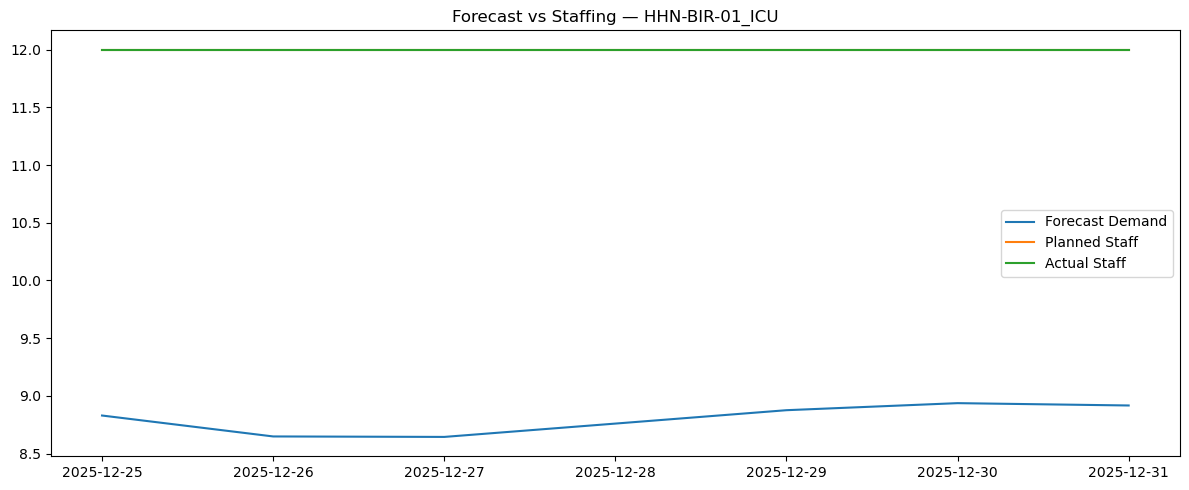

In [42]:
example_ward = "HHN-BIR-01_ICU"

trend = staffing_alignment[
    staffing_alignment["unit"] == example_ward
]

plt.figure(figsize=(12,5))
plt.plot(trend["date"], trend["predicted"], label="Forecast Demand")
plt.plot(trend["date"], trend["planned_staff"], label="Planned Staff")
plt.plot(trend["date"], trend["actual_staff"], label="Actual Staff")

plt.title(f"Forecast vs Staffing — {example_ward}")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
staffing_alignment.to_csv("../Staffing Analysis/staffing_alignment_detailed.csv", index=False)
hospital_summary.to_csv("../Staffing Analysis/hospital_staffing_summary.csv", index=False)
ward_summary.to_csv("../Staffing Analysis/ward_staffing_summary.csv", index=False)
highest_risk.to_csv("../Staffing Analysis/highest_risks_wards.csv", index=False)

print("All staffing analysis files saved successfully!")

All staffing analysis files saved successfully!
